In [2]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1783565628.557753     725 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783565629.241200     725 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783565633.709461     725 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
dir = "data"

In [6]:
builder = tfds.builder_from_directory(dir)

In [8]:
dataset = builder.as_data_source(split='train')

In [9]:
print("Dataset features:", builder.info.features)
print(f"Total examples in train split: {builder.info.splits['train'].num_examples}")
print("-" * 50)

Dataset features: FeaturesDict({
    'episode_id': string,
    'steps': Dataset({
        'action': FeaturesDict({
            'future/axis_angle_residual': Tensor(shape=(30,), dtype=float32, description=The next 10 actions for the rotation. Each action is a 3D delta to add to the current axis angle.),
            'future/target_close': Tensor(shape=(10,), dtype=int64, description=The next 10 actions for the gripper. Each action is the value the gripper closure should be changed to (notably it is *not* a delta.)),
            'future/xyz_residual': Tensor(shape=(30,), dtype=float32, description=The next 10 actions for the positions. Each action is a 3D delta to add to current position.),
        }),
        'is_first': bool,
        'is_last': bool,
        'is_terminal': bool,
        'observation': FeaturesDict({
            'episode_success': float32,
            'image': Image(shape=(171, 213, 3), dtype=uint8, description=Camera image of the robot, downsampled 3x),
            'nat

In [10]:
iterator = iter(dataset)

In [11]:
episode = next(iterator)

In [12]:
episode.keys()

dict_keys(['episode_id', 'steps'])

In [14]:
episodes = list(episode['steps'])

In [15]:
len(episodes)

88

In [16]:
episodes[0].keys()

dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])

In [18]:
episodes[0]['action'].keys()

dict_keys(['future/axis_angle_residual', 'future/target_close', 'future/xyz_residual'])

In [19]:
episodes[0]['observation'].keys()

dict_keys(['episode_success', 'image', 'natural_language_embedding', 'natural_language_instruction', 'present/autonomous', 'present/axis_angle', 'present/intervention', 'present/sensed_close', 'present/xyz', 'sequence_length'])

In [31]:
episodes[0]['action']['future/xyz_residual'].reshape(10,3)

array([[-0.0005972 , -0.00026939,  0.01102732],
       [ 0.00726835,  0.00335686,  0.02207386],
       [ 0.01773372,  0.00999449,  0.02981084],
       [ 0.04216459,  0.01980109,  0.03193229],
       [ 0.06832644,  0.06497148,  0.06103092],
       [ 0.09605751,  0.11881518,  0.09457892],
       [ 0.085801  ,  0.13284275,  0.11628845],
       [ 0.08515493,  0.1323342 ,  0.11644688],
       [ 0.08297325,  0.1283938 ,  0.1117733 ],
       [ 0.07831354,  0.12160055,  0.09931588]], dtype=float32)

In [30]:
episodes[0]['action']['future/xyz_residual'].reshape(3,10)

array([[-0.0005972 , -0.00026939,  0.01102732,  0.00726835,  0.00335686,
         0.02207386,  0.01773372,  0.00999449,  0.02981084,  0.04216459],
       [ 0.01980109,  0.03193229,  0.06832644,  0.06497148,  0.06103092,
         0.09605751,  0.11881518,  0.09457892,  0.085801  ,  0.13284275],
       [ 0.11628845,  0.08515493,  0.1323342 ,  0.11644688,  0.08297325,
         0.1283938 ,  0.1117733 ,  0.07831354,  0.12160055,  0.09931588]],
      dtype=float32)

In [35]:
episodes[2]['observation']['present/xyz']

array([-0.10646671,  0.1027852 ,  0.70269775], dtype=float32)

In [37]:
episodes[1]['action']['future/xyz_residual'].reshape(10,3)[0] + episodes[1]['observation']['present/xyz']

array([-0.10707527,  0.10251591,  0.71372306], dtype=float32)

In [39]:
episodes[0]['action']['future/xyz_residual'].reshape(10,3)[2]

array([0.01773372, 0.00999449, 0.02981084], dtype=float32)

In [40]:
episodes[1]['action']['future/xyz_residual'].reshape(10,3)[1]

array([0.00726135, 0.00335479, 0.02207554], dtype=float32)

In [43]:
type(episodes[0]['observation']['natural_language_instruction'])

bytes

In [47]:
episodes[0]['observation']['image'].shape

(171, 213, 3)

In [49]:
from PIL import Image
from IPython import display

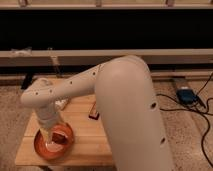

In [67]:
Image.fromarray(episodes[80]['observation']['image'])

In [66]:
episodes[80]['observation']['present/sensed_close']

array([0.2], dtype=float32)

Total episodes defined in metadata: 39350


Processing Episodes:   0%|          | 100/39350 [00:08<53:07, 12.31it/s] 



Stopped early at episode 100. Reason: Hit a missing shard file.
Successfully loaded and analyzed 100 episodes.

             DATASET STATISTICS

[ PRESENT XYZ STATS ]
Min:  [-0.4740932  -0.17937987  0.54858905]
Max:  [0.41156545 0.35196918 1.0271158 ]
Mean: [0.02795858 0.11841846 0.7893773 ]
Std:  [0.19242796 0.09735535 0.088128  ]

[ FUTURE XYZ RESIDUAL STATS ]
Min:  [-0.5693124  -0.4374168  -0.28674445]
Max:  [0.58292645 0.33354443 0.3364764 ]
Mean: [-0.02599907  0.00361136  0.01682544]
Std:  [0.09780588 0.07071946 0.06258386]

[ EPISODE LENGTH STATS ]
Min:    9
Max:    201
Mean:   132.90
Median: 141.0
p_05:   23.95
p_95:   201.0


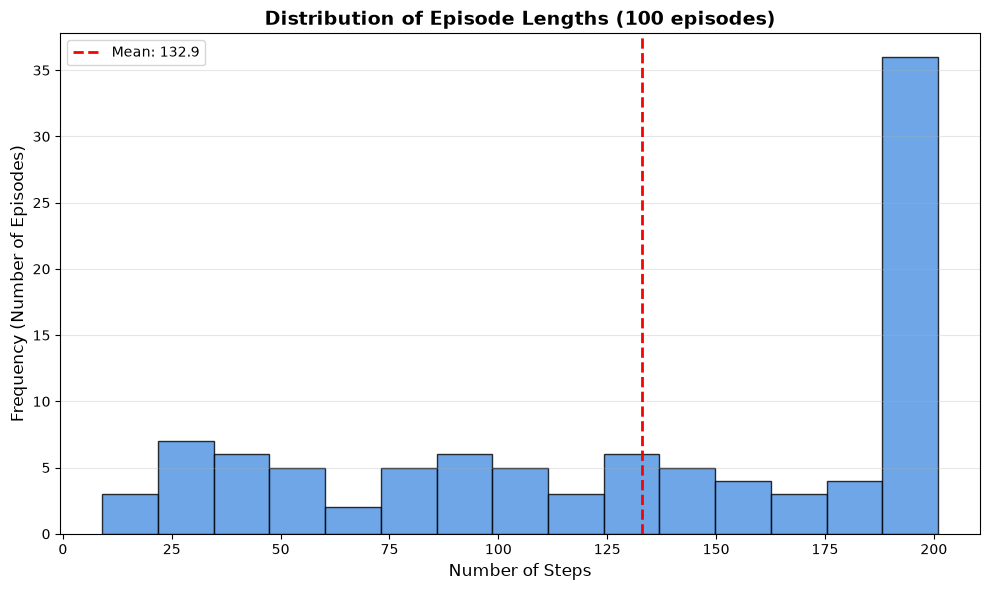

In [71]:
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. Load the dataset using as_data_source
builder_dir = 'data'
builder = tfds.builder_from_directory(builder_dir)
dataset = builder.as_data_source(split='train')

print(f"Total episodes defined in metadata: {len(dataset)}")

# Accumulators
present_xyz_list = []
future_xyz_list = []
episode_lengths = []
episodes_processed = 0

# 2. Iterate through episodes with error handling for missing shards
# We use tqdm to show progress, but it will stop early when a shard is missing
for i in tqdm(range(len(dataset)), desc="Processing Episodes"):
    try:
        episode = dataset[i]
        steps = list(episode['steps'])
        
        # Episode length stat
        episode_lengths.append(len(steps))
        
        # Extract states for this episode
        for step in steps:
            present_xyz_list.append(step['observation']['present/xyz'])
            
            # Reshape the 30-dim flat array to (10, 3) 
            future_xyz = step['action']['future/xyz_residual'].reshape(10, 3)
            future_xyz_list.append(future_xyz)
            
        episodes_processed += 1
        
    except RuntimeError as e:
        # This catches the "open() failed: No such file or directory" error
        # which happens when we hit a shard that isn't downloaded
        print(f"\nStopped early at episode {i}. Reason: Hit a missing shard file.")
        break
    except Exception as e:
        print(f"\nStopped early at episode {i}. Error: {e}")
        break

print(f"Successfully loaded and analyzed {episodes_processed} episodes.")

if episodes_processed == 0:
    print("No episodes were loaded. Please check if your shard 00000 exists.")
else:
    # Convert accumulators to numpy arrays for vectorized math
    present_xyz_arr = np.array(present_xyz_list)
    future_xyz_arr = np.array(future_xyz_list)
    episode_lengths_arr = np.array(episode_lengths)
    
    print("\n" + "="*50)
    print("             DATASET STATISTICS")
    print("="*50)
    
    # --- Present & Future Stats ---
    print("\n[ PRESENT XYZ STATS ]")
    print(f"Min:  {np.min(present_xyz_arr, axis=0)}")
    print(f"Max:  {np.max(present_xyz_arr, axis=0)}")
    print(f"Mean: {np.mean(present_xyz_arr, axis=0)}")
    print(f"Std:  {np.std(present_xyz_arr, axis=0)}")
    
    print("\n[ FUTURE XYZ RESIDUAL STATS ]")
    print(f"Min:  {np.min(future_xyz_arr, axis=(0, 1))}") 
    print(f"Max:  {np.max(future_xyz_arr, axis=(0, 1))}")
    print(f"Mean: {np.mean(future_xyz_arr, axis=(0, 1))}")
    print(f"Std:  {np.std(future_xyz_arr, axis=(0, 1))}")
    
    # --- Length Stats ---
    print("\n[ EPISODE LENGTH STATS ]")
    print(f"Min:    {np.min(episode_lengths_arr)}")
    print(f"Max:    {np.max(episode_lengths_arr)}")
    print(f"Mean:   {np.mean(episode_lengths_arr):.2f}")
    print(f"Median: {np.median(episode_lengths_arr)}")
    print(f"p_05:   {np.percentile(episode_lengths_arr, 5)}")
    print(f"p_95:   {np.percentile(episode_lengths_arr, 95)}")
    
    # --- Plotting Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(episode_lengths_arr, bins=15, color='#4A90E2', edgecolor='black', alpha=0.8)
    plt.title(f'Distribution of Episode Lengths ({episodes_processed} episodes)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Steps', fontsize=12)
    plt.ylabel('Frequency (Number of Episodes)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    # Add a vertical line for the mean
    plt.axvline(np.mean(episode_lengths_arr), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(episode_lengths_arr):.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
